# Advanced Battery Prognostics & Uncertainty

## NASA Li-ion Battery Remaining Useful Life Analysis

This notebook extends the causal SOH and RUL modelling framework developed in the previous stages by introducing uncertainty-aware and degradation-trajectory-based battery prognostics.

### Objectives

1. Reconstruct validated discharge-level degradation histories for multiple NASA batteries.
2. Engineer causal degradation features using only information available at prediction time.
3. Quantify uncertainty associated with SOH and RUL predictions.
4. Evaluate prediction intervals in addition to point-estimate accuracy.
5. Analyse uncertainty behaviour as batteries approach End of Life (EOL).
6. Investigate degradation-rate-based EOL forecasting.
7. Compare point prediction accuracy with prognostic reliability and calibration.
8. Identify conditions under which RUL predictions should be treated as low-confidence.

### Prognostic principles

- `cycle` represents sequential discharge-cycle count.
- `record_index` is retained only for source-data traceability.
- Future observations are never used to construct predictive features.
- Validation remains chronological.
- Discharge-cycle number is not used as a direct RUL predictor.
- EOL is defined as the first measured discharge cycle at or below 80% SOH.
- RUL is expressed in remaining discharge cycles until EOL.
- Point predictions and uncertainty estimates are evaluated separately.
- Prediction intervals are assessed using both coverage and interval width.
- Cross-battery conclusions are limited to the cells actually evaluated.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from nasa_loader import load_nasa_battery
from battery_features import (
    add_soh_features,
    add_degradation_features,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Source directory: {SRC_DIR}")

Project root: C:\Users\Drago\Battery-Analytics-Portfolio
Data directory: C:\Users\Drago\Battery-Analytics-Portfolio\data\raw
Source directory: C:\Users\Drago\Battery-Analytics-Portfolio\src


In [2]:
# ---------------------------------------------------------
# Load and validate NASA battery datasets
# ---------------------------------------------------------

b0005 = load_nasa_battery(
    DATA_DIR / "B0005.mat",
    "B0005",
)

b0006 = load_nasa_battery(
    DATA_DIR / "B0006.mat",
    "B0006",
)

b0005 = add_soh_features(b0005)
b0005 = add_degradation_features(b0005)

b0006 = add_soh_features(b0006)
b0006 = add_degradation_features(b0006)

for name, df in {
    "B0005": b0005,
    "B0006": b0006,
}.items():

    assert df["cycle"].equals(
        df["discharge_cycle"]
    )

    assert df["cycle"].iloc[0] == 1

    assert df["cycle"].iloc[-1] == len(df)

    print(
        f"{name}: "
        f"{len(df)} discharge cycles | "
        f"Initial capacity = "
        f"{df['capacity_Ah'].iloc[0]:.4f} Ah | "
        f"Final capacity = "
        f"{df['capacity_Ah'].iloc[-1]:.4f} Ah | "
        f"Final SOH = "
        f"{df['SOH_percent'].iloc[-1]:.2f}%"
    )

B0005: 168 discharge cycles | Initial capacity = 1.8565 Ah | Final capacity = 1.3251 Ah | Final SOH = 71.38%
B0006: 168 discharge cycles | Initial capacity = 2.0353 Ah | Final capacity = 1.1857 Ah | Final SOH = 58.25%


In [3]:
# ---------------------------------------------------------
# End-of-Life definition
# ---------------------------------------------------------

EOL_THRESHOLD = 80.0


def get_eol_cycle(
    df,
    threshold=EOL_THRESHOLD,
):
    """
    Return the first measured discharge cycle
    at or below the specified SOH threshold.
    """

    eol_rows = df.loc[
        df["SOH_percent"] <= threshold
    ]

    if eol_rows.empty:
        raise ValueError(
            f"No EOL crossing found at "
            f"{threshold:.1f}% SOH."
        )

    return int(
        eol_rows.iloc[0]["cycle"]
    )


b0005_eol_cycle = get_eol_cycle(b0005)
b0006_eol_cycle = get_eol_cycle(b0006)

print(
    f"B0005 observed EOL cycle: "
    f"{b0005_eol_cycle}"
)

print(
    f"B0006 observed EOL cycle: "
    f"{b0006_eol_cycle}"
)

B0005 observed EOL cycle: 101
B0006 observed EOL cycle: 61


In [4]:
# ---------------------------------------------------------
# Causal degradation feature engineering
# ---------------------------------------------------------

def add_causal_features(
    df,
    window=5,
):
    """
    Create past-only degradation features.

    All lagged and rolling quantities use only
    observations available before the current
    discharge cycle.
    """

    df = (
        df.copy()
        .sort_values("cycle")
        .reset_index(drop=True)
    )

    # One-cycle historical features
    df["SOH_lag1"] = (
        df["SOH_percent"]
        .shift(1)
    )

    df["capacity_lag1"] = (
        df["capacity_Ah"]
        .shift(1)
    )

    # Past-only signals
    past_soh = (
        df["SOH_percent"]
        .shift(1)
    )

    past_capacity = (
        df["capacity_Ah"]
        .shift(1)
    )

    past_temperature = (
        df["max_temperature_C"]
        .shift(1)
    )

    past_voltage = (
        df["avg_voltage_V"]
        .shift(1)
    )

    # Rolling degradation statistics
    df["SOH_roll_mean_5"] = (
        past_soh
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["SOH_roll_std_5"] = (
        past_soh
        .rolling(
            window=window,
            min_periods=window,
        )
        .std()
    )

    df["capacity_roll_mean_5"] = (
        past_capacity
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["temp_roll_mean_5"] = (
        past_temperature
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    df["voltage_roll_mean_5"] = (
        past_voltage
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

    # Five-cycle historical rates
    df["SOH_delta_5"] = (
        df["SOH_percent"].shift(1)
        - df["SOH_percent"].shift(6)
    ) / 5

    df["capacity_delta_5"] = (
        df["capacity_Ah"].shift(1)
        - df["capacity_Ah"].shift(6)
    ) / 5

    df["temperature_delta_5"] = (
        df["max_temperature_C"].shift(1)
        - df["max_temperature_C"].shift(6)
    ) / 5

    return df

In [5]:
b0005_model = add_causal_features(b0005)
b0006_model = add_causal_features(b0006)

causal_features = [
    "SOH_lag1",
    "SOH_roll_mean_5",
    "SOH_roll_std_5",
    "SOH_delta_5",
    "temp_roll_mean_5",
    "temperature_delta_5",
    "voltage_roll_mean_5",
]

for name, df in {
    "B0005": b0005_model,
    "B0006": b0006_model,
}.items():

    complete_rows = (
        df[causal_features]
        .dropna()
    )

    print(
        f"{name}: "
        f"{len(complete_rows)} complete causal rows | "
        f"First usable cycle = "
        f"{int(df.loc[complete_rows.index[0], 'cycle'])}"
    )

B0005: 162 complete causal rows | First usable cycle = 7
B0006: 162 complete causal rows | First usable cycle = 7


## Uncertainty-Aware RUL Prediction

Point predictions alone do not indicate how reliable a Remaining Useful Life estimate is.

This section introduces prediction intervals using split conformal prediction. The objective is not only to estimate RUL, but also to quantify an interval that is expected to contain the true RUL with a specified empirical coverage level.

The conformal procedure uses three chronological subsets:

1. Training set — used to fit the regression model.
2. Calibration set — used to estimate prediction-error magnitude.
3. Test set — used only for final evaluation.

No future test observations are used during model fitting or interval calibration.

The initial experiment uses B0005 pre-EOL observations and Ridge Regression with the same causal degradation features used in the previous notebook.

In [6]:
# ---------------------------------------------------------
# Construct B0005 causal RUL dataset
# ---------------------------------------------------------

b0005_rul = (
    b0005_model.loc[
        b0005_model["cycle"] < b0005_eol_cycle
    ]
    .copy()
)

b0005_rul["RUL_cycles"] = (
    b0005_eol_cycle
    - b0005_rul["cycle"]
)

b0005_rul = (
    b0005_rul
    .dropna(
        subset=causal_features
        + ["RUL_cycles"]
    )
    .reset_index(drop=True)
)

print(
    f"B0005 RUL observations: "
    f"{len(b0005_rul)}"
)

print(
    f"Cycle range: "
    f"{b0005_rul['cycle'].min()} "
    f"to "
    f"{b0005_rul['cycle'].max()}"
)

print(
    f"RUL range: "
    f"{b0005_rul['RUL_cycles'].min()} "
    f"to "
    f"{b0005_rul['RUL_cycles'].max()}"
)

B0005 RUL observations: 94
Cycle range: 7 to 100
RUL range: 1 to 94


In [7]:
# ---------------------------------------------------------
# Chronological train / calibration / test split
# ---------------------------------------------------------

n = len(b0005_rul)

train_end = int(0.60 * n)
cal_end = int(0.80 * n)

train_df = (
    b0005_rul.iloc[:train_end]
    .copy()
)

cal_df = (
    b0005_rul.iloc[train_end:cal_end]
    .copy()
)

test_df = (
    b0005_rul.iloc[cal_end:]
    .copy()
)

print(
    f"Training observations: "
    f"{len(train_df)} | "
    f"Cycles "
    f"{train_df['cycle'].min()}-"
    f"{train_df['cycle'].max()}"
)

print(
    f"Calibration observations: "
    f"{len(cal_df)} | "
    f"Cycles "
    f"{cal_df['cycle'].min()}-"
    f"{cal_df['cycle'].max()}"
)

print(
    f"Testing observations: "
    f"{len(test_df)} | "
    f"Cycles "
    f"{test_df['cycle'].min()}-"
    f"{test_df['cycle'].max()}"
)

Training observations: 56 | Cycles 7-62
Calibration observations: 19 | Cycles 63-81
Testing observations: 19 | Cycles 82-100


In [8]:
# ---------------------------------------------------------
# Model matrices
# ---------------------------------------------------------

X_train = train_df[causal_features]
y_train = train_df["RUL_cycles"]

X_cal = cal_df[causal_features]
y_cal = cal_df["RUL_cycles"]

X_test = test_df[causal_features]
y_test = test_df["RUL_cycles"]

print(
    f"X_train shape: {X_train.shape}"
)

print(
    f"X_cal shape: {X_cal.shape}"
)

print(
    f"X_test shape: {X_test.shape}"
)

X_train shape: (56, 7)
X_cal shape: (19, 7)
X_test shape: (19, 7)


In [9]:
# ---------------------------------------------------------
# Fit Ridge RUL model
# ---------------------------------------------------------

ridge_rul = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]
)

ridge_rul.fit(
    X_train,
    y_train,
)

cal_pred = ridge_rul.predict(X_cal)
test_pred = ridge_rul.predict(X_test)

print("Ridge model fitted successfully.")

print(
    f"Calibration MAE: "
    f"{mean_absolute_error(y_cal, cal_pred):.4f} cycles"
)

print(
    f"Test MAE: "
    f"{mean_absolute_error(y_test, test_pred):.4f} cycles"
)

print(
    f"Test RMSE: "
    f"{mean_squared_error(y_test, test_pred) ** 0.5:.4f} cycles"
)

print(
    f"Test R²: "
    f"{r2_score(y_test, test_pred):.4f}"
)

Ridge model fitted successfully.
Calibration MAE: 9.0434 cycles
Test MAE: 18.1641 cycles
Test RMSE: 18.6817 cycles
Test R²: -10.6335


In [10]:
# ---------------------------------------------------------
# Split conformal calibration
# ---------------------------------------------------------

ALPHA = 0.10   # 90% prediction interval

calibration_errors = np.abs(
    y_cal.to_numpy()
    - cal_pred
)

n_cal = len(calibration_errors)

quantile_level = (
    np.ceil(
        (n_cal + 1) * (1 - ALPHA)
    )
    / n_cal
)

quantile_level = min(
    quantile_level,
    1.0,
)

q_hat = np.quantile(
    calibration_errors,
    quantile_level,
    method="higher",
)

print(
    f"Calibration observations: "
    f"{n_cal}"
)

print(
    f"Target coverage: "
    f"{(1 - ALPHA) * 100:.0f}%"
)

print(
    f"Conformal quantile level: "
    f"{quantile_level:.4f}"
)

print(
    f"Conformal error radius q_hat: "
    f"{q_hat:.4f} cycles"
)

Calibration observations: 19
Target coverage: 90%
Conformal quantile level: 0.9474
Conformal error radius q_hat: 15.1888 cycles


In [11]:
# ---------------------------------------------------------
# Construct conformal prediction intervals
# ---------------------------------------------------------

lower_bound = (
    test_pred
    - q_hat
)

upper_bound = (
    test_pred
    + q_hat
)

# RUL cannot physically be negative
lower_bound_nonnegative = np.clip(
    lower_bound,
    0,
    None,
)

test_results = pd.DataFrame(
    {
        "cycle": test_df["cycle"].to_numpy(),
        "actual_RUL": y_test.to_numpy(),
        "predicted_RUL": test_pred,
        "lower_90": lower_bound_nonnegative,
        "upper_90": upper_bound,
    }
)

test_results["covered"] = (
    (
        test_results["actual_RUL"]
        >= test_results["lower_90"]
    )
    &
    (
        test_results["actual_RUL"]
        <= test_results["upper_90"]
    )
)

test_results["interval_width"] = (
    test_results["upper_90"]
    - test_results["lower_90"]
)

display(test_results)

,cycle,actual_RUL,predicted_RUL,lower_90,upper_90,covered,interval_width
0,82,19,0.657443,0.0,15.846207,False,15.846207
1,83,18,-0.964188,0.0,14.224575,False,14.224575
2,84,17,3.480523,0.0,18.669287,True,18.669287
3,85,16,4.430972,0.0,19.619735,True,19.619735
4,86,15,-0.208600,0.0,14.980163,False,14.980163
5,87,14,-5.758532,0.0,9.430231,False,9.430231
6,88,13,-5.209957,0.0,9.978807,False,9.978807
7,89,12,-5.858868,0.0,9.329896,False,9.329896
8,90,11,-5.471811,0.0,9.716952,False,9.716952
9,91,10,-5.191778,0.0,9.996986,False,9.996986


In [12]:
# ---------------------------------------------------------
# Prediction interval evaluation
# ---------------------------------------------------------

empirical_coverage = (
    test_results["covered"]
    .mean()
)

mean_interval_width = (
    test_results["interval_width"]
    .mean()
)

median_interval_width = (
    test_results["interval_width"]
    .median()
)

print(
    f"Target coverage: "
    f"{(1 - ALPHA) * 100:.1f}%"
)

print(
    f"Observed test coverage: "
    f"{empirical_coverage * 100:.2f}%"
)

print(
    f"Mean interval width: "
    f"{mean_interval_width:.2f} cycles"
)

print(
    f"Median interval width: "
    f"{median_interval_width:.2f} cycles"
)

print(
    f"Covered observations: "
    f"{test_results['covered'].sum()} "
    f"of {len(test_results)}"
)

Target coverage: 90.0%
Observed test coverage: 26.32%
Mean interval width: 7.02 cycles
Median interval width: 9.33 cycles
Covered observations: 5 of 19


In [13]:
# ---------------------------------------------------------
# Construct physically valid conformal prediction intervals
# ---------------------------------------------------------

raw_lower = test_pred - q_hat
raw_upper = test_pred + q_hat

# RUL itself is physically non-negative.
# Clip the point prediction and BOTH interval bounds.
predicted_rul_nonnegative = np.clip(
    test_pred,
    0,
    None,
)

lower_bound = np.clip(
    raw_lower,
    0,
    None,
)

upper_bound = np.clip(
    raw_upper,
    0,
    None,
)

test_results = pd.DataFrame(
    {
        "cycle": test_df["cycle"].to_numpy(),
        "actual_RUL": y_test.to_numpy(),
        "raw_predicted_RUL": test_pred,
        "predicted_RUL": predicted_rul_nonnegative,
        "lower_90": lower_bound,
        "upper_90": upper_bound,
    }
)

test_results["covered"] = (
    (test_results["actual_RUL"] >= test_results["lower_90"])
    &
    (test_results["actual_RUL"] <= test_results["upper_90"])
)

test_results["interval_width"] = (
    test_results["upper_90"]
    - test_results["lower_90"]
)

assert (
    test_results["interval_width"] >= 0
).all()

assert (
    test_results["lower_90"] >= 0
).all()

assert (
    test_results["upper_90"] >= 0
).all()

display(test_results)

,cycle,actual_RUL,raw_predicted_RUL,predicted_RUL,lower_90,upper_90,covered,interval_width
0,82,19,0.657443,0.657443,0.0,15.846207,False,15.846207
1,83,18,-0.964188,0.000000,0.0,14.224575,False,14.224575
2,84,17,3.480523,3.480523,0.0,18.669287,True,18.669287
3,85,16,4.430972,4.430972,0.0,19.619735,True,19.619735
4,86,15,-0.208600,0.000000,0.0,14.980163,False,14.980163
5,87,14,-5.758532,0.000000,0.0,9.430231,False,9.430231
6,88,13,-5.209957,0.000000,0.0,9.978807,False,9.978807
7,89,12,-5.858868,0.000000,0.0,9.329896,False,9.329896
8,90,11,-5.471811,0.000000,0.0,9.716952,False,9.716952
9,91,10,-5.191778,0.000000,0.0,9.996986,False,9.996986


In [14]:
# ---------------------------------------------------------
# Evaluate corrected prediction intervals
# ---------------------------------------------------------

empirical_coverage = (
    test_results["covered"].mean()
)

mean_interval_width = (
    test_results["interval_width"].mean()
)

median_interval_width = (
    test_results["interval_width"].median()
)

print(
    f"Target coverage: "
    f"{(1 - ALPHA) * 100:.1f}%"
)

print(
    f"Observed test coverage: "
    f"{empirical_coverage * 100:.2f}%"
)

print(
    f"Mean interval width: "
    f"{mean_interval_width:.2f} cycles"
)

print(
    f"Median interval width: "
    f"{median_interval_width:.2f} cycles"
)

print(
    f"Covered observations: "
    f"{test_results['covered'].sum()} "
    f"of {len(test_results)}"
)

print(
    f"Minimum interval width: "
    f"{test_results['interval_width'].min():.2f} cycles"
)

Target coverage: 90.0%
Observed test coverage: 26.32%
Mean interval width: 7.62 cycles
Median interval width: 9.33 cycles
Covered observations: 5 of 19
Minimum interval width: 0.00 cycles


In [15]:
# ---------------------------------------------------------
# Diagnose calibration-to-test error drift
# ---------------------------------------------------------

cal_diagnostics = pd.DataFrame(
    {
        "cycle": cal_df["cycle"].to_numpy(),
        "actual_RUL": y_cal.to_numpy(),
        "predicted_RUL": cal_pred,
    }
)

cal_diagnostics["absolute_error"] = np.abs(
    cal_diagnostics["actual_RUL"]
    - cal_diagnostics["predicted_RUL"]
)

test_diagnostics = pd.DataFrame(
    {
        "cycle": test_df["cycle"].to_numpy(),
        "actual_RUL": y_test.to_numpy(),
        "predicted_RUL": test_pred,
    }
)

test_diagnostics["absolute_error"] = np.abs(
    test_diagnostics["actual_RUL"]
    - test_diagnostics["predicted_RUL"]
)

error_regime_summary = pd.DataFrame(
    {
        "Regime": [
            "Calibration",
            "Late-life test",
        ],
        "Cycle_start": [
            cal_diagnostics["cycle"].min(),
            test_diagnostics["cycle"].min(),
        ],
        "Cycle_end": [
            cal_diagnostics["cycle"].max(),
            test_diagnostics["cycle"].max(),
        ],
        "Mean_actual_RUL": [
            cal_diagnostics["actual_RUL"].mean(),
            test_diagnostics["actual_RUL"].mean(),
        ],
        "MAE": [
            cal_diagnostics["absolute_error"].mean(),
            test_diagnostics["absolute_error"].mean(),
        ],
        "Median_absolute_error": [
            cal_diagnostics["absolute_error"].median(),
            test_diagnostics["absolute_error"].median(),
        ],
        "Max_absolute_error": [
            cal_diagnostics["absolute_error"].max(),
            test_diagnostics["absolute_error"].max(),
        ],
    }
)

display(error_regime_summary)

,Regime,Cycle_start,Cycle_end,Mean_actual_RUL,MAE,Median_absolute_error,Max_absolute_error
0,Calibration,63,81,29.0,9.043372,8.830247,15.188764
1,Late-life test,82,100,10.0,18.164080,17.858868,26.187388


In [16]:
# ---------------------------------------------------------
# Error versus remaining useful life
# ---------------------------------------------------------

combined_diagnostics = pd.concat(
    [
        cal_diagnostics.assign(
            regime="Calibration"
        ),
        test_diagnostics.assign(
            regime="Test"
        ),
    ],
    ignore_index=True,
)

rul_error_correlation = (
    combined_diagnostics[
        ["actual_RUL", "absolute_error"]
    ]
    .corr()
    .iloc[0, 1]
)

cycle_error_correlation = (
    combined_diagnostics[
        ["cycle", "absolute_error"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"Correlation between RUL and absolute error: "
    f"{rul_error_correlation:.4f}"
)

print(
    f"Correlation between cycle and absolute error: "
    f"{cycle_error_correlation:.4f}"
)

Correlation between RUL and absolute error: -0.7826
Correlation between cycle and absolute error: 0.7826


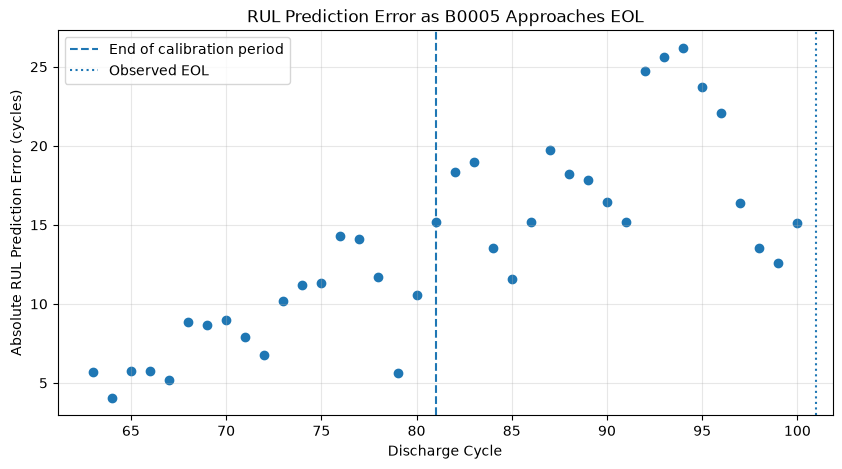

In [17]:
# ---------------------------------------------------------
# Visualise prediction-error drift toward EOL
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.scatter(
    combined_diagnostics["cycle"],
    combined_diagnostics["absolute_error"],
)

plt.axvline(
    x=cal_df["cycle"].max(),
    linestyle="--",
    label="End of calibration period",
)

plt.axvline(
    x=b0005_eol_cycle,
    linestyle=":",
    label="Observed EOL",
)

plt.xlabel("Discharge Cycle")
plt.ylabel("Absolute RUL Prediction Error (cycles)")
plt.title(
    "RUL Prediction Error as B0005 Approaches EOL"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# ---------------------------------------------------------
# Learn degradation-dependent error magnitude
# ---------------------------------------------------------

error_model = LinearRegression()

X_error_cal = cal_diagnostics[
    ["predicted_RUL"]
]

y_error_cal = cal_diagnostics[
    "absolute_error"
]

error_model.fit(
    X_error_cal,
    y_error_cal,
)

cal_expected_error = error_model.predict(
    X_error_cal
)

test_expected_error = error_model.predict(
    test_diagnostics[
        ["predicted_RUL"]
    ]
)

# Error magnitude cannot be negative
cal_expected_error = np.clip(
    cal_expected_error,
    1e-6,
    None,
)

test_expected_error = np.clip(
    test_expected_error,
    1e-6,
    None,
)

print(
    f"Error-model intercept: "
    f"{error_model.intercept_:.4f}"
)

print(
    f"Error-model coefficient: "
    f"{error_model.coef_[0]:.4f}"
)

print(
    f"Calibration expected-error range: "
    f"{cal_expected_error.min():.2f} "
    f"to {cal_expected_error.max():.2f} cycles"
)

print(
    f"Test expected-error range: "
    f"{test_expected_error.min():.2f} "
    f"to {test_expected_error.max():.2f} cycles"
)

Error-model intercept: 16.1566
Error-model coefficient: -0.3564
Calibration expected-error range: 4.41 to 14.44 cycles
Test expected-error range: 14.58 to 23.00 cycles


In [19]:
# ---------------------------------------------------------
# Adaptive conformal calibration
# ---------------------------------------------------------

adaptive_scores = (
    calibration_errors
    / cal_expected_error
)

adaptive_q_hat = np.quantile(
    adaptive_scores,
    quantile_level,
    method="higher",
)

print(
    f"Adaptive conformal quantile: "
    f"{adaptive_q_hat:.4f}"
)

print(
    f"Adaptive score minimum: "
    f"{adaptive_scores.min():.4f}"
)

print(
    f"Adaptive score median: "
    f"{np.median(adaptive_scores):.4f}"
)

print(
    f"Adaptive score maximum: "
    f"{adaptive_scores.max():.4f}"
)

Adaptive conformal quantile: 1.2284
Adaptive score minimum: 0.5470
Adaptive score median: 1.0384
Adaptive score maximum: 1.2284


In [20]:
# ---------------------------------------------------------
# Adaptive prediction intervals
# ---------------------------------------------------------

adaptive_radius = (
    adaptive_q_hat
    * test_expected_error
)

adaptive_lower = np.clip(
    test_pred - adaptive_radius,
    0,
    None,
)

adaptive_upper = np.clip(
    test_pred + adaptive_radius,
    0,
    None,
)

adaptive_results = pd.DataFrame(
    {
        "cycle": test_df["cycle"].to_numpy(),
        "actual_RUL": y_test.to_numpy(),
        "predicted_RUL": np.clip(
            test_pred,
            0,
            None,
        ),
        "expected_error": test_expected_error,
        "adaptive_radius": adaptive_radius,
        "lower_90": adaptive_lower,
        "upper_90": adaptive_upper,
    }
)

adaptive_results["covered"] = (
    (adaptive_results["actual_RUL"]
     >= adaptive_results["lower_90"])
    &
    (adaptive_results["actual_RUL"]
     <= adaptive_results["upper_90"])
)

adaptive_results["interval_width"] = (
    adaptive_results["upper_90"]
    - adaptive_results["lower_90"]
)

display(adaptive_results)

,cycle,actual_RUL,predicted_RUL,expected_error,adaptive_radius,lower_90,upper_90,covered,interval_width
0,82,19,0.657443,15.922255,19.559387,0.0,20.216830,True,20.216830
1,83,18,0.000000,16.500259,20.269425,0.0,19.305237,True,19.305237
2,84,17,3.480523,14.916013,18.323289,0.0,21.803813,True,21.803813
3,85,16,4.430972,14.577241,17.907131,0.0,22.338103,True,22.338103
4,86,15,0.000000,16.230942,19.938588,0.0,19.729988,True,19.729988
5,87,14,0.000000,18.209125,22.368649,0.0,16.610117,True,16.610117
6,88,13,0.000000,18.013594,22.128453,0.0,16.918496,True,16.918496
7,89,12,0.000000,18.244888,22.412582,0.0,16.553714,True,16.553714
8,90,11,0.000000,18.106928,22.243107,0.0,16.771296,True,16.771296
9,91,10,0.000000,18.007115,22.120494,0.0,16.928716,True,16.928716


In [21]:
# ---------------------------------------------------------
# Adaptive interval performance
# ---------------------------------------------------------

adaptive_coverage = (
    adaptive_results["covered"].mean()
)

adaptive_mean_width = (
    adaptive_results[
        "interval_width"
    ].mean()
)

adaptive_median_width = (
    adaptive_results[
        "interval_width"
    ].median()
)

print("Fixed conformal interval")
print(
    f"  Coverage: "
    f"{empirical_coverage * 100:.2f}%"
)
print(
    f"  Mean width: "
    f"{mean_interval_width:.2f} cycles"
)

print()

print("Adaptive conformal interval")
print(
    f"  Coverage: "
    f"{adaptive_coverage * 100:.2f}%"
)
print(
    f"  Mean width: "
    f"{adaptive_mean_width:.2f} cycles"
)
print(
    f"  Median width: "
    f"{adaptive_median_width:.2f} cycles"
)
print(
    f"  Covered: "
    f"{adaptive_results['covered'].sum()} "
    f"of {len(adaptive_results)}"
)

Fixed conformal interval
  Coverage: 26.32%
  Mean width: 7.62 cycles

Adaptive conformal interval
  Coverage: 100.00%
  Mean width: 15.26 cycles
  Median width: 16.55 cycles
  Covered: 19 of 19


In [22]:
# ---------------------------------------------------------
# Diagnose adaptive interval informativeness
# ---------------------------------------------------------

zero_lower_fraction = (
    adaptive_results["lower_90"]
    .eq(0)
    .mean()
)

mean_radius = (
    adaptive_results["adaptive_radius"]
    .mean()
)

median_radius = (
    adaptive_results["adaptive_radius"]
    .median()
)

mean_actual_rul = (
    adaptive_results["actual_RUL"]
    .mean()
)

width_to_rul_ratio = (
    adaptive_results["interval_width"]
    / adaptive_results["actual_RUL"]
)

print(
    f"Intervals with lower bound = 0: "
    f"{zero_lower_fraction * 100:.2f}%"
)

print(
    f"Mean adaptive radius: "
    f"{mean_radius:.2f} cycles"
)

print(
    f"Median adaptive radius: "
    f"{median_radius:.2f} cycles"
)

print(
    f"Mean actual test RUL: "
    f"{mean_actual_rul:.2f} cycles"
)

print(
    f"Mean interval-width / actual-RUL ratio: "
    f"{width_to_rul_ratio.mean():.2f}"
)

print(
    f"Median interval-width / actual-RUL ratio: "
    f"{width_to_rul_ratio.median():.2f}"
)

Intervals with lower bound = 0: 100.00%
Mean adaptive radius: 23.42 cycles
Median adaptive radius: 22.41 cycles
Mean actual test RUL: 10.00 cycles
Mean interval-width / actual-RUL ratio: 2.49
Median interval-width / actual-RUL ratio: 1.38


In [23]:
# ---------------------------------------------------------
# Interval score
# Lower is better:
# narrow intervals are rewarded,
# misses are strongly penalized.
# ---------------------------------------------------------

def interval_score(
    actual,
    lower,
    upper,
    alpha=0.10,
):
    actual = np.asarray(actual)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    width = upper - lower

    below_penalty = (
        (2 / alpha)
        * (lower - actual)
        * (actual < lower)
    )

    above_penalty = (
        (2 / alpha)
        * (actual - upper)
        * (actual > upper)
    )

    return (
        width
        + below_penalty
        + above_penalty
    )


fixed_scores = interval_score(
    test_results["actual_RUL"],
    test_results["lower_90"],
    test_results["upper_90"],
    alpha=ALPHA,
)

adaptive_scores_test = interval_score(
    adaptive_results["actual_RUL"],
    adaptive_results["lower_90"],
    adaptive_results["upper_90"],
    alpha=ALPHA,
)

print("90% interval comparison")
print()

print(
    f"Fixed conformal mean interval score: "
    f"{fixed_scores.mean():.2f}"
)

print(
    f"Adaptive conformal mean interval score: "
    f"{adaptive_scores_test.mean():.2f}"
)

print()

print(
    f"Fixed coverage: "
    f"{test_results['covered'].mean() * 100:.2f}%"
)

print(
    f"Adaptive coverage: "
    f"{adaptive_results['covered'].mean() * 100:.2f}%"
)

print()

print(
    f"Fixed mean width: "
    f"{test_results['interval_width'].mean():.2f}"
)

print(
    f"Adaptive mean width: "
    f"{adaptive_results['interval_width'].mean():.2f}"
)

90% interval comparison

Fixed conformal mean interval score: 65.22
Adaptive conformal mean interval score: 15.26

Fixed coverage: 26.32%
Adaptive coverage: 100.00%

Fixed mean width: 7.62
Adaptive mean width: 15.26


In [24]:
# ---------------------------------------------------------
# Expanding-window residual generation
# ---------------------------------------------------------

MIN_TRAIN_SIZE = 30

historical_residuals = []

for i in range(
    MIN_TRAIN_SIZE,
    len(train_df),
):

    expanding_train = train_df.iloc[:i]

    validation_row = train_df.iloc[[i]]

    X_expanding = expanding_train[
        causal_features
    ]

    y_expanding = expanding_train[
        "RUL_cycles"
    ]

    X_validation = validation_row[
        causal_features
    ]

    y_validation = float(
        validation_row[
            "RUL_cycles"
        ].iloc[0]
    )

    expanding_model = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "ridge",
                Ridge(alpha=1.0),
            ),
        ]
    )

    expanding_model.fit(
        X_expanding,
        y_expanding,
    )

    validation_prediction = float(
        expanding_model.predict(
            X_validation
        )[0]
    )

    historical_residuals.append(
        {
            "cycle": int(
                validation_row[
                    "cycle"
                ].iloc[0]
            ),
            "actual_RUL": y_validation,
            "predicted_RUL":
                validation_prediction,
            "absolute_error": abs(
                y_validation
                - validation_prediction
            ),
        }
    )


historical_residuals = pd.DataFrame(
    historical_residuals
)

print(
    f"Historical out-of-sample residuals: "
    f"{len(historical_residuals)}"
)

print(
    f"Residual cycle range: "
    f"{historical_residuals['cycle'].min()}-"
    f"{historical_residuals['cycle'].max()}"
)

print(
    f"Historical residual MAE: "
    f"{historical_residuals['absolute_error'].mean():.4f}"
)

display(
    historical_residuals.head()
)

Historical out-of-sample residuals: 26
Residual cycle range: 37-62
Historical residual MAE: 5.9208


,cycle,actual_RUL,predicted_RUL,absolute_error
0,37,64.0,71.378313,7.378313
1,38,63.0,69.633203,6.633203
2,39,62.0,67.114286,5.114286
3,40,61.0,63.413707,2.413707
4,41,60.0,66.960658,6.960658


In [25]:
# ---------------------------------------------------------
# Train uncertainty-scale model on historical residuals
# ---------------------------------------------------------

error_model_clean = LinearRegression()

error_model_clean.fit(
    historical_residuals[
        ["predicted_RUL"]
    ],
    historical_residuals[
        "absolute_error"
    ],
)

historical_expected_error = (
    error_model_clean.predict(
        historical_residuals[
            ["predicted_RUL"]
        ]
    )
)

historical_expected_error = np.clip(
    historical_expected_error,
    1e-6,
    None,
)

print(
    f"Clean error-model intercept: "
    f"{error_model_clean.intercept_:.4f}"
)

print(
    f"Clean error-model coefficient: "
    f"{error_model_clean.coef_[0]:.4f}"
)

print(
    f"Expected historical-error range: "
    f"{historical_expected_error.min():.2f} "
    f"to "
    f"{historical_expected_error.max():.2f} cycles"
)

Clean error-model intercept: -9.7470
Clean error-model coefficient: 0.2796
Expected historical-error range: 0.65 to 11.06 cycles


In [26]:
# ---------------------------------------------------------
# Clean adaptive conformal calibration
# ---------------------------------------------------------

cal_expected_error_clean = (
    error_model_clean.predict(
        cal_diagnostics[
            ["predicted_RUL"]
        ]
    )
)

cal_expected_error_clean = np.clip(
    cal_expected_error_clean,
    1e-6,
    None,
)

clean_adaptive_scores = (
    calibration_errors
    / cal_expected_error_clean
)

clean_adaptive_q_hat = np.quantile(
    clean_adaptive_scores,
    quantile_level,
    method="higher",
)

print(
    f"Clean adaptive conformal quantile: "
    f"{clean_adaptive_q_hat:.4f}"
)

print(
    f"Calibration expected-error range: "
    f"{cal_expected_error_clean.min():.2f} "
    f"to "
    f"{cal_expected_error_clean.max():.2f}"
)

print(
    f"Normalized calibration score range: "
    f"{clean_adaptive_scores.min():.2f} "
    f"to "
    f"{clean_adaptive_scores.max():.2f}"
)

Clean adaptive conformal quantile: 15188763.7149
Calibration expected-error range: 0.00 to 0.00
Normalized calibration score range: 4046851.47 to 15188763.71


In [27]:
# ---------------------------------------------------------
# Diagnose uncertainty-model extrapolation failure
# ---------------------------------------------------------

diagnostic_ranges = pd.DataFrame(
    {
        "Dataset": [
            "Historical residual training",
            "Conformal calibration",
            "Final test",
        ],

        "Cycle_min": [
            historical_residuals["cycle"].min(),
            cal_diagnostics["cycle"].min(),
            test_diagnostics["cycle"].min(),
        ],

        "Cycle_max": [
            historical_residuals["cycle"].max(),
            cal_diagnostics["cycle"].max(),
            test_diagnostics["cycle"].max(),
        ],

        "Predicted_RUL_min": [
            historical_residuals["predicted_RUL"].min(),
            cal_diagnostics["predicted_RUL"].min(),
            test_diagnostics["predicted_RUL"].min(),
        ],

        "Predicted_RUL_max": [
            historical_residuals["predicted_RUL"].max(),
            cal_diagnostics["predicted_RUL"].max(),
            test_diagnostics["predicted_RUL"].max(),
        ],
    }
)

display(diagnostic_ranges)

print()
print("Historical error-model equation:")
print(
    f"Expected error = "
    f"{error_model_clean.intercept_:.4f} "
    f"+ ({error_model_clean.coef_[0]:.4f}) × predicted_RUL"
)

zero_crossing = (
    -error_model_clean.intercept_
    / error_model_clean.coef_[0]
)

print(
    f"\nExpected-error model reaches zero at "
    f"predicted RUL ≈ {zero_crossing:.2f} cycles"
)

print(
    f"Calibration predicted-RUL range: "
    f"{cal_diagnostics['predicted_RUL'].min():.2f} "
    f"to "
    f"{cal_diagnostics['predicted_RUL'].max():.2f}"
)

print(
    f"Test predicted-RUL range: "
    f"{test_diagnostics['predicted_RUL'].min():.2f} "
    f"to "
    f"{test_diagnostics['predicted_RUL'].max():.2f}"
)

,Dataset,Cycle_min,Cycle_max,Predicted_RUL_min,Predicted_RUL_max
0,Historical residual training,37,62,37.182135,74.423098
1,Conformal calibration,63,81,4.811236,32.953149
2,Final test,82,100,-19.187388,4.430972



Historical error-model equation:
Expected error = -9.7470 + (0.2796) × predicted_RUL

Expected-error model reaches zero at predicted RUL ≈ 34.86 cycles
Calibration predicted-RUL range: 4.81 to 32.95
Test predicted-RUL range: -19.19 to 4.43


## Degradation-Trajectory-Based EOL Forecasting

Direct RUL regression can become unstable near End of Life because the target is strongly time-dependent and the degradation regime changes over time.

This section uses an alternative prognostic formulation:

1. Fit a degradation trajectory using only observations available up to a given forecast cycle.
2. Extrapolate the SOH trajectory forward.
3. Estimate the future cycle at which predicted SOH reaches the 80% EOL threshold.
4. Convert that estimated EOL cycle into predicted RUL.

This formulation separates degradation modelling from the RUL target and provides a physically interpretable route to End-of-Life estimation.

In [28]:
# ---------------------------------------------------------
# Linear SOH trajectory EOL forecast
# ---------------------------------------------------------

def forecast_eol_from_soh(
    df,
    forecast_cycle,
    threshold=80.0,
    min_history=20,
):
    """
    Fit a linear SOH-vs-cycle degradation model using
    observations available up to forecast_cycle and
    estimate the future cycle at which SOH reaches
    the specified EOL threshold.
    """

    history = (
        df.loc[
            df["cycle"] <= forecast_cycle,
            ["cycle", "SOH_percent"],
        ]
        .dropna()
        .copy()
    )

    if len(history) < min_history:
        return np.nan

    model = LinearRegression()

    X = history[["cycle"]]
    y = history["SOH_percent"]

    model.fit(X, y)

    slope = model.coef_[0]
    intercept = model.intercept_

    # SOH must decline for a meaningful forward EOL forecast
    if slope >= 0:
        return np.nan

    estimated_eol_cycle = (
        threshold - intercept
    ) / slope

    return float(estimated_eol_cycle)

In [29]:
# ---------------------------------------------------------
# Evaluate evolving EOL forecasts for B0005
# ---------------------------------------------------------

forecast_cycles = [
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
]

trajectory_results = []

for fc in forecast_cycles:

    estimated_eol = forecast_eol_from_soh(
        b0005,
        forecast_cycle=fc,
        threshold=EOL_THRESHOLD,
    )

    if np.isnan(estimated_eol):
        predicted_rul = np.nan
        eol_error = np.nan
    else:
        predicted_rul = (
            estimated_eol - fc
        )

        eol_error = (
            estimated_eol
            - b0005_eol_cycle
        )

    actual_rul = (
        b0005_eol_cycle - fc
    )

    trajectory_results.append(
        {
            "forecast_cycle": fc,
            "actual_RUL": actual_rul,
            "estimated_EOL_cycle": estimated_eol,
            "predicted_RUL": predicted_rul,
            "EOL_error_cycles": eol_error,
        }
    )

trajectory_results = pd.DataFrame(
    trajectory_results
)

display(trajectory_results)

,forecast_cycle,actual_RUL,estimated_EOL_cycle,predicted_RUL,EOL_error_cycles
0,30,71,389.293385,359.293385,288.293385
1,40,61,333.644531,293.644531,232.644531
2,50,51,228.628800,178.628800,127.628800
3,60,41,176.451619,116.451619,75.451619
4,70,31,138.582652,68.582652,37.582652
5,80,21,119.658142,39.658142,18.658142
6,90,11,111.070838,21.070838,10.070838
7,100,1,108.289644,8.289644,7.289644


In [30]:
# ---------------------------------------------------------
# Rolling-window SOH trajectory EOL forecast
# ---------------------------------------------------------

def forecast_eol_from_recent_soh(
    df,
    forecast_cycle,
    window=20,
    threshold=80.0,
):
    """
    Estimate EOL using a linear SOH trajectory fitted
    only to the most recent observations available
    at the forecast cycle.
    """

    history = (
        df.loc[
            df["cycle"] <= forecast_cycle,
            ["cycle", "SOH_percent"],
        ]
        .dropna()
        .tail(window)
        .copy()
    )

    if len(history) < window:
        return np.nan, np.nan

    model = LinearRegression()

    model.fit(
        history[["cycle"]],
        history["SOH_percent"],
    )

    slope = float(model.coef_[0])
    intercept = float(model.intercept_)

    # A forward EOL crossing requires declining SOH
    if slope >= 0:
        return np.nan, slope

    estimated_eol_cycle = (
        threshold - intercept
    ) / slope

    return (
        float(estimated_eol_cycle),
        slope,
    )

In [31]:
# ---------------------------------------------------------
# Compare global and local trajectory forecasts
# ---------------------------------------------------------

window_sizes = [
    20,
    30,
    40,
]

forecast_cycles = [
    50,
    60,
    70,
    80,
    90,
    100,
]

local_trajectory_results = []

for fc in forecast_cycles:

    global_eol = forecast_eol_from_soh(
        b0005,
        forecast_cycle=fc,
        threshold=EOL_THRESHOLD,
    )

    local_trajectory_results.append(
        {
            "forecast_cycle": fc,
            "method": "Global history",
            "window": fc,
            "estimated_EOL": global_eol,
            "EOL_error": (
                global_eol
                - b0005_eol_cycle
            ),
        }
    )

    for window in window_sizes:

        estimated_eol, slope = (
            forecast_eol_from_recent_soh(
                b0005,
                forecast_cycle=fc,
                window=window,
                threshold=EOL_THRESHOLD,
            )
        )

        local_trajectory_results.append(
            {
                "forecast_cycle": fc,
                "method": f"Recent {window}",
                "window": window,
                "estimated_EOL": estimated_eol,
                "EOL_error": (
                    estimated_eol
                    - b0005_eol_cycle
                    if not np.isnan(
                        estimated_eol
                    )
                    else np.nan
                ),
            }
        )


local_trajectory_results = pd.DataFrame(
    local_trajectory_results
)

display(
    local_trajectory_results
)

,forecast_cycle,method,window,estimated_EOL,EOL_error
0,50,Global history,50,228.628800,127.628800
1,50,Recent 20,20,117.185600,16.185600
2,50,Recent 30,30,139.603150,38.603150
3,50,Recent 40,40,212.986181,111.986181
4,60,Global history,60,176.451619,75.451619
5,60,Recent 20,20,119.765568,18.765568
6,60,Recent 30,30,113.886628,12.886628
7,60,Recent 40,40,126.495279,25.495279
8,70,Global history,70,138.582652,37.582652
9,70,Recent 20,20,90.492513,-10.507487


In [32]:
# ---------------------------------------------------------
# Summarise EOL forecast accuracy by trajectory method
# ---------------------------------------------------------

trajectory_summary = (
    local_trajectory_results
    .assign(
        absolute_EOL_error=lambda x:
            np.abs(x["EOL_error"])
    )
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        forecasts=("EOL_error", "count"),
        MAE_EOL_cycles=(
            "absolute_EOL_error",
            "mean",
        ),
        median_abs_error=(
            "absolute_EOL_error",
            "median",
        ),
        mean_bias=(
            "EOL_error",
            "mean",
        ),
        max_abs_error=(
            "absolute_EOL_error",
            "max",
        ),
    )
    .sort_values(
        "MAE_EOL_cycles"
    )
)

display(
    trajectory_summary
)

,method,forecasts,MAE_EOL_cycles,median_abs_error,mean_bias,max_abs_error
1,Recent 20,6,9.705073,9.036092,3.408255,18.765568
2,Recent 30,6,11.422637,6.481326,6.411731,38.603150
3,Recent 40,6,25.051950,5.706282,21.161121,111.986181
0,Global history,6,46.113616,28.120397,46.113616,127.628800


In [33]:
# ---------------------------------------------------------
# Rolling-origin trajectory evaluation across all cycles
# ---------------------------------------------------------

evaluation_cycles = range(
    40,
    b0005_eol_cycle,
)

window_sizes = [
    20,
    30,
    40,
]

rolling_trajectory_results = []

for fc in evaluation_cycles:

    # Global-history forecast
    global_eol = forecast_eol_from_soh(
        b0005,
        forecast_cycle=fc,
        threshold=EOL_THRESHOLD,
    )

    rolling_trajectory_results.append(
        {
            "forecast_cycle": fc,
            "actual_RUL": b0005_eol_cycle - fc,
            "method": "Global history",
            "estimated_EOL": global_eol,
            "predicted_RUL": (
                global_eol - fc
                if not np.isnan(global_eol)
                else np.nan
            ),
            "EOL_error": (
                global_eol - b0005_eol_cycle
                if not np.isnan(global_eol)
                else np.nan
            ),
        }
    )

    # Recent-window forecasts
    for window in window_sizes:

        estimated_eol, slope = (
            forecast_eol_from_recent_soh(
                b0005,
                forecast_cycle=fc,
                window=window,
                threshold=EOL_THRESHOLD,
            )
        )

        rolling_trajectory_results.append(
            {
                "forecast_cycle": fc,
                "actual_RUL": b0005_eol_cycle - fc,
                "method": f"Recent {window}",
                "estimated_EOL": estimated_eol,
                "predicted_RUL": (
                    estimated_eol - fc
                    if not np.isnan(estimated_eol)
                    else np.nan
                ),
                "EOL_error": (
                    estimated_eol - b0005_eol_cycle
                    if not np.isnan(estimated_eol)
                    else np.nan
                ),
            }
        )


rolling_trajectory_results = pd.DataFrame(
    rolling_trajectory_results
)

rolling_trajectory_results[
    "absolute_EOL_error"
] = np.abs(
    rolling_trajectory_results[
        "EOL_error"
    ]
)

print(
    f"Forecast cycles evaluated: "
    f"{min(evaluation_cycles)}-"
    f"{max(evaluation_cycles)}"
)

print(
    f"Total forecast records: "
    f"{len(rolling_trajectory_results)}"
)

Forecast cycles evaluated: 40-100
Total forecast records: 244


In [34]:
# ---------------------------------------------------------
# Overall rolling-origin trajectory performance
# ---------------------------------------------------------

rolling_summary = (
    rolling_trajectory_results
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        valid_forecasts=(
            "EOL_error",
            "count",
        ),
        MAE_EOL_cycles=(
            "absolute_EOL_error",
            "mean",
        ),
        median_abs_error=(
            "absolute_EOL_error",
            "median",
        ),
        mean_bias=(
            "EOL_error",
            "mean",
        ),
        max_abs_error=(
            "absolute_EOL_error",
            "max",
        ),
    )
    .sort_values(
        "MAE_EOL_cycles"
    )
)

display(
    rolling_summary
)

,method,valid_forecasts,MAE_EOL_cycles,median_abs_error,mean_bias,max_abs_error
1,Recent 20,61,15.725596,9.485195,8.540887,59.064021
2,Recent 30,61,28.600087,8.795659,23.373915,299.951500
3,Recent 40,61,41.777292,7.827044,37.949308,232.644531
0,Global history,61,60.892194,37.582652,60.892194,232.644531


In [35]:
# ---------------------------------------------------------
# Evaluate trajectory accuracy by prognostic horizon
# ---------------------------------------------------------

rolling_trajectory_results[
    "RUL_regime"
] = pd.cut(
    rolling_trajectory_results[
        "actual_RUL"
    ],
    bins=[
        0,
        10,
        20,
        40,
        np.inf,
    ],
    labels=[
        "1-10 cycles",
        "11-20 cycles",
        "21-40 cycles",
        ">40 cycles",
    ],
)

regime_summary = (
    rolling_trajectory_results
    .groupby(
        [
            "method",
            "RUL_regime",
        ],
        observed=True,
        as_index=False,
    )
    .agg(
        forecasts=(
            "EOL_error",
            "count",
        ),
        MAE_EOL_cycles=(
            "absolute_EOL_error",
            "mean",
        ),
        mean_bias=(
            "EOL_error",
            "mean",
        ),
    )
    .sort_values(
        [
            "RUL_regime",
            "MAE_EOL_cycles",
        ]
    )
)

display(
    regime_summary
)

,method,RUL_regime,forecasts,MAE_EOL_cycles,mean_bias
8,Recent 30,1-10 cycles,10,1.562960,0.888040
12,Recent 40,1-10 cycles,10,1.908772,-1.908772
4,Recent 20,1-10 cycles,10,6.957548,6.957548
0,Global history,1-10 cycles,10,8.852991,8.852991
5,Recent 20,11-20 cycles,10,6.111499,-6.111499
9,Recent 30,11-20 cycles,10,7.323574,-7.323574
13,Recent 40,11-20 cycles,10,7.349156,-7.349156
1,Global history,11-20 cycles,10,12.828743,12.828743
14,Recent 40,21-40 cycles,20,7.088168,4.670743
10,Recent 30,21-40 cycles,20,7.763620,-0.515172


In [36]:
# ---------------------------------------------------------
# Prognostic-horizon reliability analysis
# ---------------------------------------------------------

reliability_thresholds = [
    5,
    10,
    15,
]

reliability_records = []

for method in (
    rolling_trajectory_results["method"].unique()
):

    method_df = (
        rolling_trajectory_results.loc[
            rolling_trajectory_results["method"]
            == method
        ]
        .sort_values("forecast_cycle")
        .copy()
    )

    for threshold in reliability_thresholds:

        within_threshold = (
            method_df["absolute_EOL_error"]
            <= threshold
        )

        reliability_records.append(
            {
                "method": method,
                "error_threshold_cycles": threshold,
                "fraction_within_threshold":
                    within_threshold.mean(),
                "forecasts_within_threshold":
                    within_threshold.sum(),
                "total_forecasts":
                    len(method_df),
            }
        )


reliability_summary = pd.DataFrame(
    reliability_records
)

display(reliability_summary)

,method,error_threshold_cycles,fraction_within_threshold,forecasts_within_threshold,total_forecasts
0,Global history,5,0.000000,0,61
1,Global history,10,0.147541,9,61
2,Global history,15,0.278689,17,61
3,Recent 20,5,0.114754,7,61
4,Recent 20,10,0.573770,35,61
5,Recent 20,15,0.721311,44,61
6,Recent 30,5,0.262295,16,61
7,Recent 30,10,0.573770,35,61
8,Recent 30,15,0.672131,41,61
9,Recent 40,5,0.344262,21,61


In [37]:
# ---------------------------------------------------------
# Earliest sustained reliable forecast cycle
# ---------------------------------------------------------

sustained_records = []

for method in (
    rolling_trajectory_results["method"].unique()
):

    method_df = (
        rolling_trajectory_results.loc[
            rolling_trajectory_results["method"]
            == method
        ]
        .sort_values("forecast_cycle")
        .reset_index(drop=True)
    )

    for threshold in reliability_thresholds:

        sustained_cycle = np.nan

        for i in range(len(method_df)):

            future_errors = (
                method_df.loc[
                    i:,
                    "absolute_EOL_error"
                ]
            )

            if (
                future_errors.notna().all()
                and
                (
                    future_errors
                    <= threshold
                ).all()
            ):
                sustained_cycle = int(
                    method_df.loc[
                        i,
                        "forecast_cycle"
                    ]
                )
                break

        if np.isnan(sustained_cycle):
            actual_rul_at_onset = np.nan
        else:
            actual_rul_at_onset = (
                b0005_eol_cycle
                - sustained_cycle
            )

        sustained_records.append(
            {
                "method": method,
                "error_threshold_cycles":
                    threshold,
                "sustained_from_cycle":
                    sustained_cycle,
                "actual_RUL_at_onset":
                    actual_rul_at_onset,
            }
        )


sustained_reliability = pd.DataFrame(
    sustained_records
)

display(sustained_reliability)

,method,error_threshold_cycles,sustained_from_cycle,actual_RUL_at_onset
0,Global history,5,NaN,NaN
1,Global history,10,93.0,8.0
2,Global history,15,84.0,17.0
3,Recent 20,5,100.0,1.0
4,Recent 20,10,73.0,28.0
5,Recent 20,15,61.0,40.0
6,Recent 30,5,90.0,11.0
7,Recent 30,10,78.0,23.0
8,Recent 30,15,60.0,41.0
9,Recent 40,5,91.0,10.0


In [38]:
# ---------------------------------------------------------
# Late-life trajectory predictions: cycles 82-100
# ---------------------------------------------------------

comparison_cycles = test_df["cycle"].to_numpy()

trajectory_comparison = []

for fc in comparison_cycles:

    actual_rul = (
        b0005_eol_cycle - fc
    )

    for window in [20, 30, 40]:

        estimated_eol, slope = (
            forecast_eol_from_recent_soh(
                b0005,
                forecast_cycle=fc,
                window=window,
                threshold=EOL_THRESHOLD,
            )
        )

        predicted_rul = (
            estimated_eol - fc
            if not np.isnan(estimated_eol)
            else np.nan
        )

        # Physical RUL constraint
        predicted_rul = (
            max(predicted_rul, 0)
            if not np.isnan(predicted_rul)
            else np.nan
        )

        trajectory_comparison.append(
            {
                "cycle": fc,
                "actual_RUL": actual_rul,
                "method": f"Trajectory-{window}",
                "predicted_RUL": predicted_rul,
                "SOH_slope": slope,
            }
        )


trajectory_comparison = pd.DataFrame(
    trajectory_comparison
)

display(
    trajectory_comparison.head(9)
)

,cycle,actual_RUL,method,predicted_RUL,SOH_slope
0,82,19,Trajectory-20,11.735847,-0.322822
1,82,19,Trajectory-30,10.675007,-0.341240
2,82,19,Trajectory-40,12.256846,-0.319759
3,83,18,Trajectory-20,11.274356,-0.314451
4,83,18,Trajectory-30,10.034416,-0.336463
5,83,18,Trajectory-40,10.978949,-0.323758
6,84,17,Trajectory-20,10.569999,-0.310076
7,84,17,Trajectory-30,9.408206,-0.331191
8,84,17,Trajectory-40,9.726943,-0.327776


In [39]:
# ---------------------------------------------------------
# Add causal Ridge predictions
# ---------------------------------------------------------

ridge_comparison = pd.DataFrame(
    {
        "cycle": test_df["cycle"].to_numpy(),
        "actual_RUL": y_test.to_numpy(),
        "method": "Causal Ridge",
        "predicted_RUL": np.clip(
            test_pred,
            0,
            None,
        ),
    }
)

comparison_results = pd.concat(
    [
        ridge_comparison,
        trajectory_comparison[
            [
                "cycle",
                "actual_RUL",
                "method",
                "predicted_RUL",
            ]
        ],
    ],
    ignore_index=True,
)

comparison_results[
    "error"
] = (
    comparison_results["predicted_RUL"]
    - comparison_results["actual_RUL"]
)

comparison_results[
    "absolute_error"
] = np.abs(
    comparison_results["error"]
)

display(
    comparison_results.head()
)

,cycle,actual_RUL,method,predicted_RUL,error,absolute_error
0,82,19,Causal Ridge,0.657443,-18.342557,18.342557
1,83,18,Causal Ridge,0.000000,-18.000000,18.000000
2,84,17,Causal Ridge,3.480523,-13.519477,13.519477
3,85,16,Causal Ridge,4.430972,-11.569028,11.569028
4,86,15,Causal Ridge,0.000000,-15.000000,15.000000


In [40]:
# ---------------------------------------------------------
# Apples-to-apples late-life prognostic comparison
# ---------------------------------------------------------

late_life_summary = (
    comparison_results
    .dropna(
        subset=[
            "actual_RUL",
            "predicted_RUL",
        ]
    )
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        observations=(
            "absolute_error",
            "count",
        ),
        MAE=(
            "absolute_error",
            "mean",
        ),
        RMSE=(
            "error",
            lambda x:
                np.sqrt(
                    np.mean(
                        np.square(x)
                    )
                ),
        ),
        bias=(
            "error",
            "mean",
        ),
        max_absolute_error=(
            "absolute_error",
            "max",
        ),
    )
    .sort_values("MAE")
)

display(late_life_summary)

,method,observations,MAE,RMSE,bias,max_absolute_error
2,Trajectory-30,19,4.222803,5.155651,-2.932803,8.324993
3,Trajectory-40,19,4.543971,5.447487,-4.543971,8.514514
1,Trajectory-20,19,6.484427,6.751878,0.839308,9.375243
0,Causal Ridge,19,9.549003,10.802212,-9.549003,18.342557


In [41]:
# ---------------------------------------------------------
# Add R² for each late-life prognostic method
# ---------------------------------------------------------

r2_records = []

for method, group in comparison_results.groupby(
    "method"
):

    valid = group.dropna(
        subset=[
            "actual_RUL",
            "predicted_RUL",
        ]
    )

    r2_records.append(
        {
            "method": method,
            "R2": r2_score(
                valid["actual_RUL"],
                valid["predicted_RUL"],
            ),
        }
    )

r2_summary = pd.DataFrame(
    r2_records
)

late_life_summary = (
    late_life_summary.merge(
        r2_summary,
        on="method",
        how="left",
    )
)

display(late_life_summary)

,method,observations,MAE,RMSE,bias,max_absolute_error,R2
0,Trajectory-30,19,4.222803,5.155651,-2.932803,8.324993,0.113975
1,Trajectory-40,19,4.543971,5.447487,-4.543971,8.514514,0.010830
2,Trajectory-20,19,6.484427,6.751878,0.839308,9.375243,-0.519595
3,Causal Ridge,19,9.549003,10.802212,-9.549003,18.342557,-2.889593


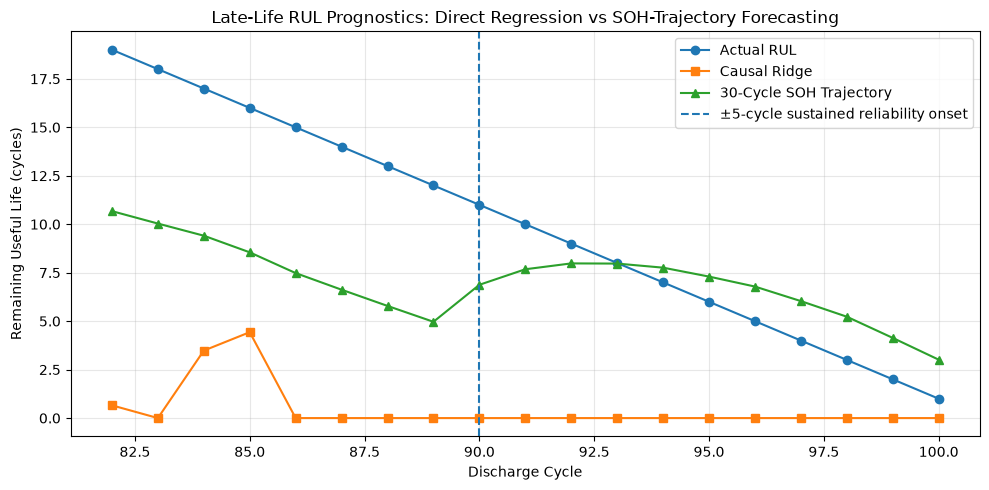

In [42]:
# ---------------------------------------------------------
# Compare late-life RUL trajectories
# ---------------------------------------------------------

plot_comparison = (
    comparison_results.loc[
        comparison_results["method"].isin(
            [
                "Causal Ridge",
                "Trajectory-30",
            ]
        )
    ]
    .pivot(
        index="cycle",
        columns="method",
        values="predicted_RUL",
    )
)

actual_series = (
    comparison_results.loc[
        comparison_results["method"]
        == "Causal Ridge",
        ["cycle", "actual_RUL"],
    ]
    .drop_duplicates()
    .set_index("cycle")
)

plt.figure(figsize=(10, 5))

plt.plot(
    actual_series.index,
    actual_series["actual_RUL"],
    marker="o",
    label="Actual RUL",
)

plt.plot(
    plot_comparison.index,
    plot_comparison["Causal Ridge"],
    marker="s",
    label="Causal Ridge",
)

plt.plot(
    plot_comparison.index,
    plot_comparison["Trajectory-30"],
    marker="^",
    label="30-Cycle SOH Trajectory",
)

plt.axvline(
    x=90,
    linestyle="--",
    label="±5-cycle sustained reliability onset",
)

plt.xlabel("Discharge Cycle")
plt.ylabel("Remaining Useful Life (cycles)")
plt.title(
    "Late-Life RUL Prognostics: "
    "Direct Regression vs SOH-Trajectory Forecasting"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# ---------------------------------------------------------
# Analyse optimistic versus conservative RUL errors
# ---------------------------------------------------------

safety_records = []

for method, group in comparison_results.groupby(
    "method"
):

    valid = group.dropna(
        subset=[
            "actual_RUL",
            "predicted_RUL",
        ]
    ).copy()

    errors = (
        valid["predicted_RUL"]
        - valid["actual_RUL"]
    )

    optimistic = errors > 0
    conservative = errors < 0

    safety_records.append(
        {
            "method": method,

            "optimistic_predictions":
                int(optimistic.sum()),

            "conservative_predictions":
                int(conservative.sum()),

            "optimistic_fraction":
                optimistic.mean(),

            "mean_optimistic_error":
                errors.loc[
                    optimistic
                ].mean()
                if optimistic.any()
                else 0.0,

            "max_optimistic_error":
                errors.loc[
                    optimistic
                ].max()
                if optimistic.any()
                else 0.0,

            "mean_conservative_error":
                errors.loc[
                    conservative
                ].mean()
                if conservative.any()
                else 0.0,
        }
    )


safety_summary = pd.DataFrame(
    safety_records
).sort_values(
    "optimistic_fraction"
)

display(safety_summary)

,method,optimistic_predictions,conservative_predictions,optimistic_fraction,mean_optimistic_error,max_optimistic_error,mean_conservative_error
0,Causal Ridge,0,19,0.000000,0.000000,0.000000,-9.549003
3,Trajectory-40,0,19,0.000000,0.000000,0.000000,-4.543971
2,Trajectory-30,7,12,0.368421,1.750714,2.229509,-5.664854
1,Trajectory-20,10,9,0.526316,6.957548,9.375243,-5.958737


## Cross-Battery Validation of the Selected Trajectory Model

The 30-cycle SOH trajectory estimator was selected using B0005 only.

For cross-battery validation, the window length is now frozen at 30 cycles and evaluated on B0006 without retuning.

This provides an external cell-level test of whether the degradation-trajectory formulation transfers beyond the battery used for model development.

In [44]:
# ---------------------------------------------------------
# Locked 30-cycle trajectory validation on B0006
# ---------------------------------------------------------

LOCKED_WINDOW = 30

b0006_forecast_cycles = range(
    LOCKED_WINDOW,
    b0006_eol_cycle,
)

b0006_trajectory_records = []

for fc in b0006_forecast_cycles:

    estimated_eol, slope = (
        forecast_eol_from_recent_soh(
            b0006,
            forecast_cycle=fc,
            window=LOCKED_WINDOW,
            threshold=EOL_THRESHOLD,
        )
    )

    actual_rul = (
        b0006_eol_cycle - fc
    )

    if np.isnan(estimated_eol):
        predicted_rul = np.nan
        eol_error = np.nan
    else:
        predicted_rul = (
            estimated_eol - fc
        )

        # Physical RUL constraint
        predicted_rul = max(
            predicted_rul,
            0,
        )

        eol_error = (
            predicted_rul
            - actual_rul
        )

    b0006_trajectory_records.append(
        {
            "cycle": fc,
            "actual_RUL": actual_rul,
            "estimated_EOL": estimated_eol,
            "predicted_RUL": predicted_rul,
            "SOH_slope": slope,
            "error": eol_error,
        }
    )


b0006_trajectory_results = pd.DataFrame(
    b0006_trajectory_records
)

b0006_trajectory_results[
    "absolute_error"
] = np.abs(
    b0006_trajectory_results["error"]
)

print(
    f"B0006 observed EOL cycle: "
    f"{b0006_eol_cycle}"
)

print(
    f"Locked trajectory window: "
    f"{LOCKED_WINDOW} cycles"
)

print(
    f"Forecast cycles evaluated: "
    f"{b0006_trajectory_results['cycle'].min()}-"
    f"{b0006_trajectory_results['cycle'].max()}"
)

print(
    f"Forecast observations: "
    f"{len(b0006_trajectory_results)}"
)

display(
    b0006_trajectory_results.head()
)

B0006 observed EOL cycle: 61
Locked trajectory window: 30 cycles
Forecast cycles evaluated: 30-60
Forecast observations: 31


,cycle,actual_RUL,estimated_EOL,predicted_RUL,SOH_slope,error,absolute_error
0,30,31,71.691389,41.691389,-0.269305,10.691389,10.691389
1,31,30,78.959518,47.959518,-0.239380,17.959518,17.959518
2,32,29,83.209368,51.209368,-0.223978,22.209368,22.209368
3,33,28,84.823865,51.823865,-0.218001,23.823865,23.823865
4,34,27,85.836770,51.836770,-0.213662,24.836770,24.836770


In [45]:
# ---------------------------------------------------------
# B0006 locked trajectory performance
# ---------------------------------------------------------

valid_b0006 = (
    b0006_trajectory_results
    .dropna(
        subset=[
            "actual_RUL",
            "predicted_RUL",
        ]
    )
    .copy()
)

b0006_mae = mean_absolute_error(
    valid_b0006["actual_RUL"],
    valid_b0006["predicted_RUL"],
)

b0006_rmse = np.sqrt(
    mean_squared_error(
        valid_b0006["actual_RUL"],
        valid_b0006["predicted_RUL"],
    )
)

b0006_r2 = r2_score(
    valid_b0006["actual_RUL"],
    valid_b0006["predicted_RUL"],
)

b0006_bias = (
    valid_b0006["error"].mean()
)

b0006_max_error = (
    valid_b0006[
        "absolute_error"
    ].max()
)

print(
    f"B0006 Trajectory-30 MAE: "
    f"{b0006_mae:.4f} cycles"
)

print(
    f"B0006 Trajectory-30 RMSE: "
    f"{b0006_rmse:.4f} cycles"
)

print(
    f"B0006 Trajectory-30 R²: "
    f"{b0006_r2:.4f}"
)

print(
    f"B0006 Trajectory-30 bias: "
    f"{b0006_bias:+.4f} cycles"
)

print(
    f"B0006 maximum absolute error: "
    f"{b0006_max_error:.4f} cycles"
)

B0006 Trajectory-30 MAE: 9.7180 cycles
B0006 Trajectory-30 RMSE: 12.9596 cycles
B0006 Trajectory-30 R²: -1.0994
B0006 Trajectory-30 bias: +9.4203 cycles
B0006 maximum absolute error: 24.8368 cycles


In [46]:
# ---------------------------------------------------------
# B0006 optimistic/conservative error behaviour
# ---------------------------------------------------------

optimistic = (
    valid_b0006["error"] > 0
)

conservative = (
    valid_b0006["error"] < 0
)

print(
    f"Optimistic predictions: "
    f"{optimistic.sum()} / {len(valid_b0006)} "
    f"({optimistic.mean() * 100:.2f}%)"
)

print(
    f"Conservative predictions: "
    f"{conservative.sum()} / {len(valid_b0006)} "
    f"({conservative.mean() * 100:.2f}%)"
)

if optimistic.any():

    print(
        f"Mean optimistic error: "
        f"{valid_b0006.loc[optimistic, 'error'].mean():+.2f} cycles"
    )

    print(
        f"Maximum optimistic error: "
        f"{valid_b0006.loc[optimistic, 'error'].max():+.2f} cycles"
    )

if conservative.any():

    print(
        f"Mean conservative error: "
        f"{valid_b0006.loc[conservative, 'error'].mean():+.2f} cycles"
    )

Optimistic predictions: 27 / 31 (87.10%)
Conservative predictions: 4 / 31 (12.90%)
Mean optimistic error: +10.99 cycles
Maximum optimistic error: +24.84 cycles
Mean conservative error: -1.15 cycles


In [47]:
# ---------------------------------------------------------
# B0006 trajectory performance by prognostic horizon
# ---------------------------------------------------------

b0006_horizon = (
    valid_b0006.copy()
)

b0006_horizon[
    "RUL_regime"
] = pd.cut(
    b0006_horizon["actual_RUL"],
    bins=[
        0,
        10,
        20,
        np.inf,
    ],
    labels=[
        "1-10 cycles",
        "11-20 cycles",
        ">20 cycles",
    ],
)

b0006_horizon_summary = (
    b0006_horizon
    .groupby(
        "RUL_regime",
        observed=True,
        as_index=False,
    )
    .agg(
        forecasts=(
            "absolute_error",
            "count",
        ),
        MAE=(
            "absolute_error",
            "mean",
        ),
        RMSE=(
            "error",
            lambda x: np.sqrt(
                np.mean(
                    np.square(x)
                )
            ),
        ),
        bias=(
            "error",
            "mean",
        ),
        max_absolute_error=(
            "absolute_error",
            "max",
        ),
    )
)

display(
    b0006_horizon_summary
)

,RUL_regime,forecasts,MAE,RMSE,bias,max_absolute_error
0,1-10 cycles,10,4.125456,4.312720,4.125456,5.869967
1,11-20 cycles,10,3.589293,4.755175,2.666460,10.556009
2,>20 cycles,11,20.373714,20.877078,20.373714,24.836770


In [48]:
# ---------------------------------------------------------
# Compare evolving 30-cycle SOH degradation slopes
# ---------------------------------------------------------

def calculate_rolling_soh_slope(
    df,
    window=30,
):
    records = []

    for fc in range(window, len(df) + 1):

        history = (
            df.loc[
                df["cycle"] <= fc,
                ["cycle", "SOH_percent"],
            ]
            .dropna()
            .tail(window)
        )

        if len(history) < window:
            continue

        model = LinearRegression()

        model.fit(
            history[["cycle"]],
            history["SOH_percent"],
        )

        slope = float(
            model.coef_[0]
        )

        records.append(
            {
                "cycle": fc,
                "SOH_percent":
                    float(
                        df.loc[
                            df["cycle"] == fc,
                            "SOH_percent",
                        ].iloc[0]
                    ),
                "rolling_SOH_slope":
                    slope,
            }
        )

    return pd.DataFrame(records)


b0005_slopes = calculate_rolling_soh_slope(
    b0005,
    window=LOCKED_WINDOW,
)

b0006_slopes = calculate_rolling_soh_slope(
    b0006,
    window=LOCKED_WINDOW,
)

print("B0005 slope summary:")
display(
    b0005_slopes[
        "rolling_SOH_slope"
    ].describe()
)

print("\nB0006 slope summary:")
display(
    b0006_slopes[
        "rolling_SOH_slope"
    ].describe()
)

B0005 slope summary:


count    139.000000
mean      -0.194903
std        0.083777
min       -0.374415
25%       -0.233332
50%       -0.199903
75%       -0.155105
max       -0.010110
Name: rolling_SOH_slope, dtype: float64


B0006 slope summary:


count    139.000000
mean      -0.249554
std        0.105494
min       -0.526443
25%       -0.331236
50%       -0.223032
75%       -0.168958
max       -0.087919
Name: rolling_SOH_slope, dtype: float64

In [49]:
# ---------------------------------------------------------
# Degradation slope around observed EOL
# ---------------------------------------------------------

def get_pre_eol_slope_summary(
    slope_df,
    eol_cycle,
    horizons=(30, 20, 10),
):

    records = []

    for horizon in horizons:

        start_cycle = (
            eol_cycle - horizon
        )

        subset = slope_df.loc[
            (slope_df["cycle"] >= start_cycle)
            &
            (slope_df["cycle"] < eol_cycle)
        ]

        records.append(
            {
                "horizon_before_EOL":
                    horizon,

                "start_cycle":
                    start_cycle,

                "observations":
                    len(subset),

                "mean_SOH_slope":
                    subset[
                        "rolling_SOH_slope"
                    ].mean(),

                "median_SOH_slope":
                    subset[
                        "rolling_SOH_slope"
                    ].median(),

                "min_SOH_slope":
                    subset[
                        "rolling_SOH_slope"
                    ].min(),

                "max_SOH_slope":
                    subset[
                        "rolling_SOH_slope"
                    ].max(),
            }
        )

    return pd.DataFrame(records)


print("B0005 pre-EOL degradation slopes:")

display(
    get_pre_eol_slope_summary(
        b0005_slopes,
        b0005_eol_cycle,
    )
)

print("B0006 pre-EOL degradation slopes:")

display(
    get_pre_eol_slope_summary(
        b0006_slopes,
        b0006_eol_cycle,
    )
)

B0005 pre-EOL degradation slopes:


,horizon_before_EOL,start_cycle,observations,mean_SOH_slope,median_SOH_slope,min_SOH_slope,max_SOH_slope
0,30,71,30,-0.298048,-0.323115,-0.374415,-0.208169
1,20,81,20,-0.277272,-0.275293,-0.345107,-0.208169
2,10,91,10,-0.227400,-0.221477,-0.265238,-0.208169


B0006 pre-EOL degradation slopes:


,horizon_before_EOL,start_cycle,observations,mean_SOH_slope,median_SOH_slope,min_SOH_slope,max_SOH_slope
0,30,31,30,-0.295015,-0.306413,-0.394171,-0.209165
1,20,41,20,-0.330783,-0.326229,-0.394171,-0.264583
2,10,51,10,-0.324015,-0.320179,-0.355897,-0.302120


### Degradation-Regime Interpretation

The rolling SOH analysis reveals an important difference between B0005 and B0006.

For B0005, the mean 30-cycle rolling SOH slope becomes less negative as EOL approaches:

- Final 30-cycle region: −0.298 %SOH/cycle
- Final 20-cycle region: −0.277 %SOH/cycle
- Final 10-cycle region: −0.227 %SOH/cycle

B0006 exhibits the opposite behaviour:

- Final 30-cycle region: −0.295 %SOH/cycle
- Final 20-cycle region: −0.331 %SOH/cycle
- Final 10-cycle region: −0.324 %SOH/cycle

Therefore, the two cells do not follow the same degradation-rate evolution near EOL.

This explains an important limitation of local linear trajectory extrapolation. The method assumes that the recent SOH degradation rate remains representative of the future trajectory. For B0006, forecasts made more than 20 cycles before EOL substantially underestimate the subsequent degradation rate and consequently overestimate remaining life.

The locked 30-cycle trajectory estimator therefore produced:

- RUL >20 cycles: MAE = 20.37 cycles, bias = +20.37 cycles
- RUL 11–20 cycles: MAE = 3.59 cycles, bias = +2.67 cycles
- RUL 1–10 cycles: MAE = 4.13 cycles, bias = +4.13 cycles

The trajectory model is therefore substantially more reliable at shorter prognostic horizons, but its long-horizon forecasts are not robust across cells.

This result demonstrates that battery prognostics must account for degradation-rate nonstationarity and cell-to-cell variation rather than assuming a fixed local degradation trajectory.

In [50]:
# ---------------------------------------------------------
# Strictly causal rolling SOH trajectory forecast
# ---------------------------------------------------------

def forecast_eol_from_past_soh(
    df,
    forecast_cycle,
    window=30,
    threshold=80.0,
):
    """
    Forecast EOL at discharge cycle t using SOH
    observations available only through cycle t-1.
    """

    history = (
        df.loc[
            df["cycle"] < forecast_cycle,
            ["cycle", "SOH_percent"],
        ]
        .dropna()
        .tail(window)
        .copy()
    )

    if len(history) < window:
        return np.nan, np.nan

    model = LinearRegression()

    model.fit(
        history[["cycle"]],
        history["SOH_percent"],
    )

    slope = float(model.coef_[0])
    intercept = float(model.intercept_)

    if slope >= 0:
        return np.nan, slope

    estimated_eol_cycle = (
        threshold - intercept
    ) / slope

    return float(estimated_eol_cycle), slope

In [51]:
# ---------------------------------------------------------
# Strictly causal Trajectory-30: B0005 cycles 82-100
# ---------------------------------------------------------

causal_trajectory_records = []

for fc in test_df["cycle"]:

    estimated_eol, slope = (
        forecast_eol_from_past_soh(
            b0005,
            forecast_cycle=int(fc),
            window=30,
            threshold=EOL_THRESHOLD,
        )
    )

    actual_rul = (
        b0005_eol_cycle - int(fc)
    )

    if np.isnan(estimated_eol):
        predicted_rul = np.nan
    else:
        predicted_rul = max(
            estimated_eol - int(fc),
            0,
        )

    causal_trajectory_records.append(
        {
            "cycle": int(fc),
            "actual_RUL": actual_rul,
            "predicted_RUL": predicted_rul,
            "estimated_EOL": estimated_eol,
            "SOH_slope": slope,
        }
    )


causal_trajectory_30 = pd.DataFrame(
    causal_trajectory_records
).dropna()

causal_trajectory_30["error"] = (
    causal_trajectory_30["predicted_RUL"]
    - causal_trajectory_30["actual_RUL"]
)

causal_trajectory_30["absolute_error"] = (
    causal_trajectory_30["error"].abs()
)


print(
    f"Strict-causal Trajectory-30 MAE: "
    f"{causal_trajectory_30['absolute_error'].mean():.4f} cycles"
)

print(
    f"Strict-causal Trajectory-30 RMSE: "
    f"{np.sqrt(np.mean(causal_trajectory_30['error'] ** 2)):.4f} cycles"
)

print(
    f"Strict-causal Trajectory-30 R²: "
    f"{r2_score(causal_trajectory_30['actual_RUL'], causal_trajectory_30['predicted_RUL']):.4f}"
)

print(
    f"Strict-causal Trajectory-30 bias: "
    f"{causal_trajectory_30['error'].mean():+.4f} cycles"
)

print(
    f"Maximum absolute error: "
    f"{causal_trajectory_30['absolute_error'].max():.4f} cycles"
)

Strict-causal Trajectory-30 MAE: 4.5712 cycles
Strict-causal Trajectory-30 RMSE: 5.5036 cycles
Strict-causal Trajectory-30 R²: -0.0096
Strict-causal Trajectory-30 bias: -3.4931 cycles
Maximum absolute error: 8.6321 cycles


### Strict-Causality Check

The trajectory-based EOL estimator was also evaluated under a stricter information boundary.

In the original trajectory formulation, the SOH measurement at the forecast cycle was included in the local trajectory fit. In the strict-causal formulation, an EOL forecast at cycle `t` uses SOH observations only through cycle `t-1`.

For B0005 cycles 82–100, the strict-causal 30-cycle trajectory estimator achieved:

- MAE = 4.57 cycles
- RMSE = 5.50 cycles
- Bias = −3.49 cycles
- Maximum absolute error = 8.63 cycles
- R² = −0.010

The corresponding measurement-updated trajectory estimator achieved an MAE of 4.22 cycles. Removing the current-cycle SOH measurement therefore increased MAE by only approximately 8%.

Compared with the direct causal Ridge model on the same late-life horizon, the strict-causal trajectory formulation reduced MAE from 9.55 to 4.57 cycles and RMSE from 10.80 to 5.50 cycles.

However, the near-zero R² indicates that the model does not explain late-life RUL variance strongly across this narrow evaluation range. The trajectory result should therefore be interpreted primarily through absolute-error, bias, and worst-case-error metrics rather than R² alone.

Overall, the experiment indicates that the advantage of trajectory-based EOL forecasting is not solely caused by access to the current-cycle SOH measurement.

In [52]:
# ---------------------------------------------------------
# Strict-causal locked Trajectory-30 validation on B0006
# ---------------------------------------------------------

b0006_strict_records = []

for fc in range(
    LOCKED_WINDOW + 1,
    b0006_eol_cycle,
):

    estimated_eol, slope = (
        forecast_eol_from_past_soh(
            b0006,
            forecast_cycle=fc,
            window=LOCKED_WINDOW,
            threshold=EOL_THRESHOLD,
        )
    )

    actual_rul = (
        b0006_eol_cycle - fc
    )

    if np.isnan(estimated_eol):

        predicted_rul = np.nan

    else:

        predicted_rul = max(
            estimated_eol - fc,
            0,
        )

    b0006_strict_records.append(
        {
            "cycle": fc,
            "actual_RUL": actual_rul,
            "predicted_RUL": predicted_rul,
            "estimated_EOL": estimated_eol,
            "SOH_slope": slope,
        }
    )


b0006_strict = (
    pd.DataFrame(
        b0006_strict_records
    )
    .dropna()
)

b0006_strict["error"] = (
    b0006_strict["predicted_RUL"]
    - b0006_strict["actual_RUL"]
)

b0006_strict["absolute_error"] = (
    b0006_strict["error"].abs()
)


print(
    f"Observations: "
    f"{len(b0006_strict)}"
)

print(
    f"Strict-causal B0006 Trajectory-30 MAE: "
    f"{b0006_strict['absolute_error'].mean():.4f} cycles"
)

print(
    f"Strict-causal B0006 Trajectory-30 RMSE: "
    f"{np.sqrt(np.mean(b0006_strict['error'] ** 2)):.4f} cycles"
)

print(
    f"Strict-causal B0006 Trajectory-30 R²: "
    f"{r2_score(b0006_strict['actual_RUL'], b0006_strict['predicted_RUL']):.4f}"
)

print(
    f"Strict-causal B0006 Trajectory-30 bias: "
    f"{b0006_strict['error'].mean():+.4f} cycles"
)

print(
    f"Maximum absolute error: "
    f"{b0006_strict['absolute_error'].max():.4f} cycles"
)

optimistic = (
    b0006_strict["error"] > 0
)

print(
    f"\nOptimistic predictions: "
    f"{optimistic.sum()} / {len(b0006_strict)} "
    f"({optimistic.mean() * 100:.2f}%)"
)

if optimistic.any():

    print(
        f"Mean optimistic error: "
        f"{b0006_strict.loc[optimistic, 'error'].mean():+.2f} cycles"
    )

    print(
        f"Maximum optimistic error: "
        f"{b0006_strict.loc[optimistic, 'error'].max():+.2f} cycles"
    )

Observations: 30
Strict-causal B0006 Trajectory-30 MAE: 9.9793 cycles
Strict-causal B0006 Trajectory-30 RMSE: 13.1693 cycles
Strict-causal B0006 Trajectory-30 R²: -1.3150
Strict-causal B0006 Trajectory-30 bias: +9.6716 cycles
Maximum absolute error: 24.8368 cycles

Optimistic predictions: 26 / 30 (86.67%)
Mean optimistic error: +11.34 cycles
Maximum optimistic error: +24.84 cycles


### Trajectory-Prognostics Conclusion

The trajectory-based experiments provide three distinct findings.

**1. Local degradation trajectories outperform lifetime-average extrapolation within B0005.**

A fixed global SOH slope substantially overestimated EOL because the degradation rate was not constant over battery life. Rolling recent-history trajectories adapted better to the evolving degradation regime.

Across B0005 forecast cycles 40–100, the 20-cycle trajectory produced the lowest overall EOL MAE among the tested fixed windows. However, window performance was strongly dependent on prognostic horizon, demonstrating that no single window was uniformly optimal.

**2. Trajectory-based forecasting substantially improved B0005 late-life RUL prediction.**

For cycles 82–100, the measurement-updated 30-cycle trajectory achieved an MAE of 4.22 cycles compared with 9.55 cycles for direct causal Ridge regression.

Under a stricter causal information boundary, where the forecast at cycle `t` used SOH observations only through cycle `t-1`, the 30-cycle trajectory achieved:

- MAE = 4.57 cycles
- RMSE = 5.50 cycles
- Bias = −3.49 cycles
- Maximum absolute error = 8.63 cycles
- R² = −0.010

The approximately 8% increase in MAE relative to the measurement-updated trajectory indicates that the trajectory advantage was not solely caused by access to the current-cycle SOH measurement.

**3. The selected trajectory method did not transfer reliably across cells.**

The 30-cycle window was selected using B0005 and then frozen before evaluation on B0006.

Under strict causal evaluation, B0006 produced:

- MAE = 9.98 cycles
- RMSE = 13.17 cycles
- R² = −1.32
- Bias = +9.67 cycles
- Maximum absolute error = 24.84 cycles
- Optimistic predictions = 86.7%

The aggregate failure was concentrated at longer prognostic horizons. In the measurement-updated diagnostic, MAE was 20.37 cycles when more than 20 cycles of actual RUL remained, but decreased to 3.59 cycles at 11–20 cycles RUL and 4.13 cycles during the final 10 cycles.

Rolling SOH slopes also showed different late-life behaviour between the cells. B0005 exhibited a less-negative fitted degradation slope near EOL, whereas B0006 exhibited a more-negative late-life slope. Consequently, earlier B0006 trajectories underestimated the subsequent degradation rate and produced optimistic long-horizon EOL estimates.

### Overall Interpretation

Local SOH-trajectory forecasting is a useful and physically interpretable alternative to direct RUL regression, particularly for late-life within-cell prognostics.

However, the method is not cell-invariant. Its reliability depends on prognostic horizon and on whether the recent degradation rate remains representative of future ageing.

Together with the uncertainty-calibration experiments, these results demonstrate that degradation-regime shift is a central challenge in battery prognostics. Both point-prediction accuracy and uncertainty calibration can deteriorate when future ageing dynamics differ from the historical regime used for estimation.

The results therefore support the use of explicit domain-awareness, multi-cell validation, uncertainty monitoring, and regime-sensitive prognostic models rather than unrestricted extrapolation from a single degradation trajectory.

# Conclusions

This notebook extended the battery prognostics workflow from point-estimate SOH/RUL modelling toward uncertainty-aware and degradation-trajectory-based Remaining Useful Life prediction.

The experiments demonstrate that battery prognostics is not only a regression problem. Prediction reliability depends strongly on temporal causality, degradation regime, prognostic horizon, cell-to-cell variability, and the validity of uncertainty assumptions.

## 1. Uncertainty Quantification Under Degradation Shift

A 90% split-conformal prediction interval was first constructed using a chronological training/calibration/test protocol on B0005.

The fixed conformal approach achieved:

- Nominal coverage: 90%
- Observed late-life coverage: 26.32%
- Mean interval width: 7.62 cycles

The failure was associated with substantial temporal error drift:

- Calibration MAE: 9.04 cycles
- Late-life test MAE: 18.16 cycles
- Correlation between discharge cycle and absolute prediction error: approximately +0.783

Therefore, calibration residuals from an earlier degradation regime were not representative of errors encountered later in battery life.

A diagnostic adaptive-error model increased empirical coverage to 100%, but produced highly conservative intervals:

- Mean interval width: 15.26 cycles
- 100% of lower bounds reached the physical zero-RUL boundary

Furthermore, the same calibration observations were used for both error-scale estimation and conformal-score calibration, so this experiment should not be interpreted as a formally valid adaptive-conformal procedure.

A cleaner expanding-window residual model was subsequently tested. However, the historical error-scale relationship failed to extrapolate into the later degradation regime. The fitted expected-error model crossed zero at a predicted RUL of approximately 34.86 cycles, while calibration and test predictions were largely below this range.

This caused physically invalid negative expected-error estimates and numerical instability after clipping.

The conformal experiments therefore demonstrate an important limitation:

> Prediction uncertainty itself is nonstationary during battery degradation. An uncertainty model calibrated in one ageing regime cannot automatically be assumed valid in a later regime.

---

## 2. Global versus Local SOH-Trajectory Forecasting

A second prognostic formulation estimated EOL by extrapolating SOH trajectories toward the 80% SOH threshold.

Global lifetime-history linear extrapolation performed poorly because degradation rate was not constant throughout battery life.

For B0005 forecast cycles 40–100:

- Global-history EOL MAE: 60.89 cycles
- Recent-20 EOL MAE: 15.73 cycles
- Recent-30 EOL MAE: 28.60 cycles
- Recent-40 EOL MAE: 41.78 cycles

The Recent-20 trajectory therefore provided the lowest overall error across the complete evaluated forecasting range.

However, performance depended strongly on prognostic horizon.

Near EOL, longer local windows became more effective:

- At RUL 1–10 cycles:
  - Recent-30 MAE = 1.56 cycles
  - Recent-40 MAE = 1.91 cycles
  - Recent-20 MAE = 6.96 cycles

This demonstrates that no single trajectory window was uniformly optimal across battery life.

---

## 3. Prognostic-Horizon Reliability

Trajectory reliability improved substantially as the battery approached EOL.

For B0005:

- Recent-30 remained within ±5 EOL cycles from cycle 90 onward
- This corresponds to approximately 11 cycles of actual RUL remaining
- Recent-40 achieved sustained ±5-cycle accuracy from cycle 91
- Recent-40 achieved sustained ±10-cycle accuracy from cycle 66, corresponding to 35 cycles of remaining life

These results demonstrate that EOL forecasting performance should be evaluated as a function of prognostic horizon rather than through a single aggregate error metric.

---

## 4. Direct RUL Regression versus Trajectory Forecasting

On the common B0005 late-life evaluation interval of cycles 82–100:

- Causal Ridge MAE = 9.55 cycles
- Causal Ridge RMSE = 10.80 cycles
- Causal Ridge maximum absolute error = 18.34 cycles

The measurement-updated 30-cycle trajectory achieved:

- MAE = 4.22 cycles
- RMSE = 5.16 cycles
- Maximum absolute error = 8.32 cycles

The trajectory formulation therefore reduced late-life MAE by approximately 56% relative to direct Ridge RUL regression.

However, this initial trajectory formulation included the current-cycle SOH measurement and therefore did not use exactly the same information boundary as the causal Ridge model.

---

## 5. Strict-Causality Validation

A stricter trajectory formulation was therefore evaluated in which a forecast at discharge cycle `t` used SOH measurements only through cycle `t-1`.

For B0005 cycles 82–100, the strict-causal Trajectory-30 estimator achieved:

- MAE = 4.57 cycles
- RMSE = 5.50 cycles
- Bias = −3.49 cycles
- Maximum absolute error = 8.63 cycles
- R² = −0.010

Compared with direct causal Ridge regression, strict-causal trajectory forecasting reduced:

- MAE from 9.55 to 4.57 cycles
- RMSE from 10.80 to 5.50 cycles
- Maximum absolute error from 18.34 to 8.63 cycles

Removing the current-cycle SOH measurement increased trajectory MAE by only approximately 8%.

The improvement therefore persisted under a strict causal information boundary.

The near-zero R² nevertheless indicates that the model explains little of the variance across the narrow late-life RUL range. The result should therefore be interpreted primarily using MAE, RMSE, bias, and worst-case error rather than R² alone.

---

## 6. Safety-Relevant Error Direction

Prediction bias is particularly important in prognostics because overestimating RUL can delay maintenance or replacement.

For the measurement-updated B0005 late-life experiment:

- Trajectory-30 produced optimistic predictions in 36.84% of cases
- Mean optimistic error = +1.75 cycles
- Maximum optimistic error = +2.23 cycles

Trajectory-20 was optimistic in 52.63% of cases and reached a maximum optimistic error of +9.38 cycles.

Causal Ridge and Trajectory-40 produced no optimistic predictions in this particular evaluation interval, but both systematically underestimated RUL.

This illustrates why prognostic models should be evaluated using directional error in addition to symmetric metrics such as MAE and RMSE.

---

## 7. Locked Cross-Battery Validation

The 30-cycle trajectory window was selected from the B0005 experiments and then frozen before evaluation on B0006.

No B0006 result was used to retune the window.

Under strict-causal B0006 evaluation:

- Observations = 30
- MAE = 9.98 cycles
- RMSE = 13.17 cycles
- R² = −1.32
- Bias = +9.67 cycles
- Maximum absolute error = 24.84 cycles
- Optimistic predictions = 86.67%
- Mean optimistic error = +11.34 cycles
- Maximum optimistic error = +24.84 cycles

Therefore, the strong within-cell B0005 trajectory performance did not transfer reliably to B0006.

The external-cell failure cannot be attributed primarily to access to current-cycle SOH because it remained under the strict causal information boundary.

---

## 8. Cross-Battery Degradation-Regime Differences

Rolling 30-cycle SOH slopes revealed different degradation-rate evolution between B0005 and B0006.

For B0005:

- Final 30-cycle mean slope = −0.298 %SOH/cycle
- Final 20-cycle mean slope = −0.277 %SOH/cycle
- Final 10-cycle mean slope = −0.227 %SOH/cycle

For B0006:

- Final 30-cycle mean slope = −0.295 %SOH/cycle
- Final 20-cycle mean slope = −0.331 %SOH/cycle
- Final 10-cycle mean slope = −0.324 %SOH/cycle

B0005 therefore exhibited a less-negative recent fitted degradation rate near its EOL threshold, whereas B0006 exhibited a more-negative late-life rate.

This degradation-rate nonstationarity explains much of the B0006 long-horizon optimism.

For the measurement-updated B0006 diagnostic:

- RUL >20 cycles: MAE = 20.37 cycles, bias = +20.37 cycles
- RUL 11–20 cycles: MAE = 3.59 cycles, bias = +2.67 cycles
- RUL 1–10 cycles: MAE = 4.13 cycles, bias = +4.13 cycles

The trajectory estimator therefore became substantially more useful after B0006 entered its later degradation regime.

---

# Key Finding

The central finding of this notebook is that:

> **Battery prognostic reliability is regime-dependent.**

Neither point prediction nor uncertainty calibration can be assumed to remain valid when the degradation dynamics encountered during deployment differ from those represented during model development.

The experiments show that:

1. chronological validation is essential;
2. uncertainty calibration can fail under degradation-dependent error drift;
3. recent SOH trajectories can outperform direct RUL regression for within-cell late-life prediction;
4. trajectory performance depends strongly on prognostic horizon;
5. strict causal validation is necessary to avoid information leakage;
6. degradation trajectories differ materially between cells;
7. strong within-cell performance does not imply cross-cell generalization;
8. optimistic RUL errors require explicit monitoring because they may be operationally more consequential than conservative errors.

---

# Limitations

This study has several important limitations.

- Only B0005 and B0006 were evaluated.
- Both cells originate from the same NASA ageing dataset and therefore do not represent the full diversity of real-world battery operation.
- EOL was defined using a fixed 80% SOH threshold.
- Local linear trajectories cannot represent arbitrary nonlinear degradation behaviour.
- Capacity-recovery events and measurement variability were retained rather than manually removed.
- Conformal coverage assumptions were challenged by chronological, dependent, and nonstationary degradation data.
- The adaptive uncertainty experiments were diagnostic and should not be interpreted as a deployment-ready uncertainty estimator.
- The 30-cycle trajectory window was selected using B0005 and therefore requires validation on additional unseen cells.
- Prediction intervals have not yet been validated across a sufficiently large battery population.
- Operational variables available in this dataset are limited compared with production BMS telemetry.

---

# Future Work

The next stages should focus on generalization rather than additional tuning of B0005 and B0006.

Recommended extensions include:

1. Add NASA B0007 and B0018 for multi-cell validation.
2. Perform leave-one-battery-out evaluation.
3. Train multi-cell models while preserving an independent held-out battery.
4. Quantify prediction uncertainty across cells rather than only across time within one cell.
5. Develop degradation-regime and out-of-distribution detection.
6. Investigate asymmetric or safety-aware RUL loss functions.
7. Evaluate probabilistic EOL forecasting.
8. Compare fixed-window trajectories with regime-adaptive degradation models.
9. Introduce explainable-AI analysis to identify the features driving SOH/RUL estimates.
10. Validate all model-selection decisions using leakage-safe procedures.

These extensions are addressed in the subsequent multi-battery validation and explainability stages of the project.

# Portfolio Summary

### Advanced Battery Prognostics & Uncertainty

This notebook developed and critically evaluated uncertainty-aware and trajectory-based battery prognostics using NASA Li-ion ageing data.

### Technical capabilities demonstrated

- Leakage-aware time-series validation
- Causal battery-health feature engineering
- SOH and RUL prognostics
- Split conformal prediction
- Prediction-interval coverage analysis
- Temporal error-drift diagnosis
- Adaptive uncertainty diagnostics
- Rolling SOH degradation modelling
- Threshold-based EOL forecasting
- Prognostic-horizon analysis
- Strict causal inference
- Cross-battery validation
- Safety-oriented optimistic/conservative error analysis
- Degradation-regime interpretation

### Selected results

**B0005 late-life prognostics**

- Direct causal Ridge MAE: 9.55 cycles
- Strict-causal Trajectory-30 MAE: 4.57 cycles
- Strict-causal Trajectory-30 RMSE: 5.50 cycles
- Maximum trajectory error: 8.63 cycles
- Approximately 52% MAE reduction versus direct Ridge regression

**Uncertainty analysis**

- Nominal conformal coverage: 90%
- Observed late-life coverage: 26.32%
- Calibration MAE: 9.04 cycles
- Test MAE: 18.16 cycles
- Strong degradation-dependent error drift identified

**Cross-battery validation**

- Locked strict-causal B0006 Trajectory-30 MAE: 9.98 cycles
- Bias: +9.67 cycles
- Optimistic predictions: 86.67%
- Maximum optimistic error: +24.84 cycles

### Engineering conclusion

The strongest result of this notebook is not a single high model score.

It is the demonstration that battery prognostic performance, uncertainty, and safety behaviour can change materially across degradation regimes and across cells.

A robust battery-intelligence system must therefore combine predictive modelling with causal validation, uncertainty monitoring, degradation-regime awareness, domain checks, and independent multi-cell validation.